# Frontiera Media-Varianza G5


Analisi Tecnica dell'ImplementazioneMatematica della Funzione

- Obiettivo: La funzione portfolio_variance è la traduzione letterale in algebra lineare di $w^T \Sigma w$. Il metodo SLSQP cerca di minimizzare tale valore scalare.
- Vincoli Long-Only (Bounds): Aggiungendo il vincolo (0, 1) stiamo applicando una restrizione pratica di un fondo long-only standard (no short selling e no leva). Se rimuovessi i bounds o permettessi posizioni negative (es. (-1, 1)), vedresti la frontiera espandersi ulteriormente (aumento geometrico dell'area di ottimizzazione non vincolata), introducendo però forti inefficienze legate al costo del prestito titoli e al rischio di margin call.
- Dinamica dei Singoli Asset: Come evidenzia il grafico generato, gli asset singoli (i punti) giacciono all'interno o sotto la frontiera (dominanza stocastica e geometrica). Per raggiungere quelle combinazioni di rischio, un portafoglio ottimizzato fornirà matematicamente sempre un rendimento superiore o un rischio inferiore per via della componente moltiplicativa della covarianza $\Sigma$ nel rischio di portafoglio.

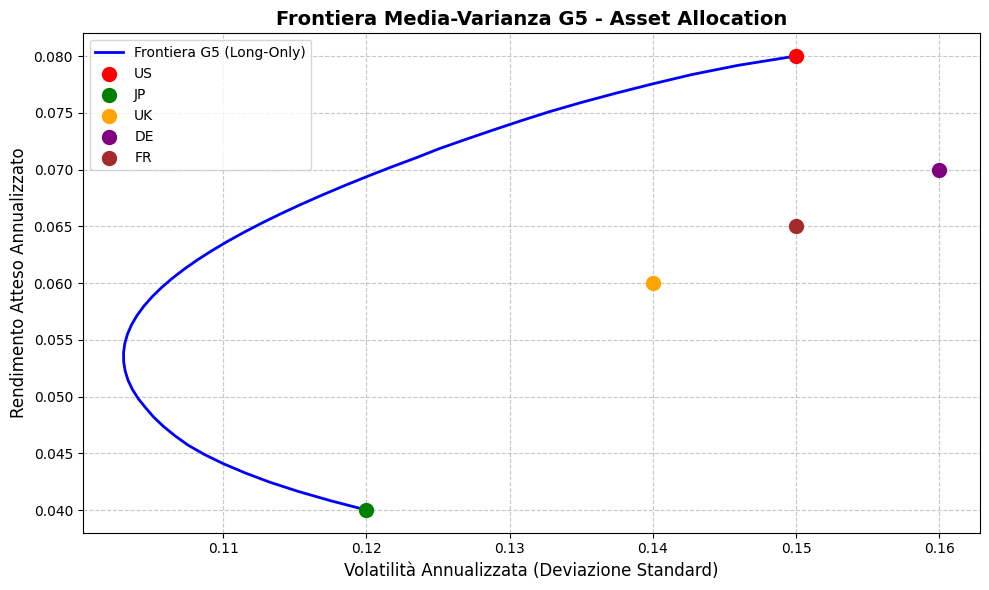

In [1]:
import numpy as np
import scipy.optimize as sco
import matplotlib.pyplot as plt

# ==========================================
# 1. DEFINIZIONE DEGLI INPUT QUANTITATIVI
# ==========================================
assets = ['US', 'JP', 'UK', 'DE', 'FR']
n_assets = len(assets)

# Vettore dei rendimenti attesi (Expected Returns - E[R])
expected_returns = np.array([0.08, 0.04, 0.06, 0.07, 0.065])

# Vettore delle volatilità (Standard Deviations)
volatilities = np.array([0.15, 0.12, 0.14, 0.16, 0.15])

# Matrice di correlazione (Correlation Matrix - rho)
corr_matrix = np.array([
    [1.00, 0.35, 0.50, 0.60, 0.55],
    [0.35, 1.00, 0.40, 0.30, 0.35],
    [0.50, 0.40, 1.00, 0.70, 0.65],
    [0.60, 0.30, 0.70, 1.00, 0.85],
    [0.55, 0.35, 0.65, 0.85, 1.00]
])

# Matrice di Covarianza (Sigma): Σ = D * R * D (dove D è la matrice diagonale delle volatilità)
D = np.diag(volatilities)
cov_matrix = D @ corr_matrix @ D

# ==========================================
# 2. FUNZIONI OBIETTIVO
# ==========================================
def portfolio_variance(weights, cov_matrix):
    """Calcola la varianza del portafoglio: w^T * Sigma * w"""
    return weights.T @ cov_matrix @ weights

def portfolio_return(weights, expected_returns):
    """Calcola il rendimento atteso del portafoglio: w^T * mu"""
    return np.sum(expected_returns * weights)

# ==========================================
# 3. OTTIMIZZAZIONE E CALCOLO FRONTIERA
# ==========================================
# Creiamo uno spazio vettoriale di 50 target di rendimento
target_returns = np.linspace(np.min(expected_returns), np.max(expected_returns), 50)
efficient_volatilities = []

# Bounds: Vincolo Long-Only (0 <= w_i <= 1 per ogni asset)
bounds = tuple((0, 1) for _ in range(n_assets))

# Guess iniziale: portafoglio equiponderato (1/N)
initial_guess = np.full(n_assets, 1.0 / n_assets)

# Ottimizzazione iterativa per ogni target return
for target in target_returns:
    # Vincoli:
    # 1. Budget constraint: somma dei pesi = 1
    # 2. Target return constraint: rendimento portafoglio = target iterato
    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: portfolio_return(w, expected_returns) - target}
    )

    # Risoluzione programmazione quadratica
    result = sco.minimize(
        portfolio_variance,
        initial_guess,
        args=(cov_matrix,),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    # Se la convergenza ha successo, salviamo la deviazione standard ottimizzata
    if result.success:
        efficient_volatilities.append(np.sqrt(result.fun))
    else:
        efficient_volatilities.append(np.nan)

# ==========================================
# 4. PLOTTING DEI RISULTATI
# ==========================================
plt.figure(figsize=(10, 6))

# Traccia la frontiera efficiente
plt.plot(efficient_volatilities, target_returns, 'b-', linewidth=2, label='Frontiera G5 (Long-Only)')

# Traccia i singoli asset (domini sub-ottimali)
colors = ['red', 'green', 'orange', 'purple', 'brown']
for i in range(n_assets):
    plt.scatter(volatilities[i], expected_returns[i], color=colors[i], marker='o', s=100, label=assets[i], zorder=5)

plt.title('Frontiera Media-Varianza G5 - Asset Allocation', fontsize=14, fontweight='bold')
plt.xlabel('Volatilità Annualizzata (Deviazione Standard)', fontsize=12)
plt.ylabel('Rendimento Atteso Annualizzato', fontsize=12)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Salva o mostra il plot
# plt.show()
plt.savefig('efficient_frontier.png')